# SMS Spam Classifier - Model Building

## Objective

The objective of this notebook is to preprocess SMS text data, convert it into numerical features using TF-IDF Vectorization, train Machine Learning models, evaluate their performance, and save the best-performing model for deployment in the Flask web application.

In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import string

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# Create stemmer object
ps = PorterStemmer()

# Load stopwords only once
STOP_WORDS = set(stopwords.words("english"))

In [39]:
ps = PorterStemmer()

In [40]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Payal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
df = pd.read_csv("../dataset/spam.csv", encoding="latin-1")

In [7]:
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])

In [8]:
df = df.rename(columns={
    "v1": "target",
    "v2": "text"
})

In [9]:
df = df.drop_duplicates(keep="first")

In [10]:
df.shape

(5169, 2)

# Text Preprocessing

In [11]:
def transform_text(text):
    pass

In [41]:
def transform_text(text):

    # Step 1: Convert to lowercase
    text = text.lower()

    # Step 2: Tokenize the text
    text = nltk.word_tokenize(text)

    # Step 3: Remove special characters
    filtered_words = []

    for word in text:
        if word.isalnum():
            filtered_words.append(word)

    # Step 4: Remove stopwords
    cleaned_words = []

    for word in filtered_words:
        if word not in STOP_WORDS:
            cleaned_words.append(word)

    # Step 5: Apply stemming
    stemmed_words = []

    for word in cleaned_words:
        stemmed_words.append(ps.stem(word))

    # Step 6: Convert list back to string
    return " ".join(stemmed_words)

In [42]:
transform_text("HELLO! How are you doing today?")

'hello today'

In [43]:
stopwords.words("english")[:20]

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been']

In [44]:
transform_text("HELLO! How are you doing today?")

'hello today'

In [45]:
ps.stem("playing")

'play'

In [46]:
ps.stem("running")

'run'

In [47]:
ps.stem("studies")

'studi'

In [48]:
transform_text("I am LOVING to PLAY football!!!")

'love play footbal'

In [49]:
df["transformed_text"] = df["text"].apply(transform_text)

In [50]:
df.head()

,target,text,transformed_text
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [51]:
df[["text", "transformed_text"]].head(10)

,text,transformed_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darl 3 week word back like fun sti...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request mell oru minnaminungint nurungu ve...
8,WINNER!! As a valued network customer you have...,winner valu network custom select receivea pri...
9,Had your mobile 11 months or more? U R entitle...,mobil 11 month u r entitl updat latest colour ...


In [52]:
print("Original Message:\n")
print(df["text"][0])

print("\nProcessed Message:\n")
print(df["transformed_text"][0])

Original Message:

Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Processed Message:

go jurong point crazi avail bugi n great world la e buffet cine got amor wat


## Text Preprocessing Summary

The `transform_text()` function was applied to every SMS message in the dataset using the `apply()` method.

The preprocessing pipeline performs the following steps:

- Converts text to lowercase.
- Tokenizes the text into individual words.
- Removes punctuation and special characters.
- Removes English stopwords.
- Applies Porter Stemming.
- Returns a cleaned text string ready for TF-IDF vectorization.

The processed text is stored in a new column named `transformed_text`.

# TF-IDF Vectorization

In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [54]:
tfidf = TfidfVectorizer(max_features=3000)

In [55]:
X = tfidf.fit_transform(df["transformed_text"]).toarray()

In [57]:
y = df["target"].map({
    "ham": 0,
    "spam": 1
})

In [58]:
X.shape

(5169, 3000)

In [59]:
y.head()

0    0
1    0
2    1
3    0
4    0
Name: target, dtype: int64

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [62]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4135, 3000)
(1034, 3000)
(4135,)
(1034,)


In [63]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


# Train-Test Split

The dataset was divided into training and testing sets using an 80:20 ratio.

- **Training Set (80%)**: Used to train the machine learning model.
- **Testing Set (20%)**: Used to evaluate the model on unseen data.

A fixed `random_state` of 42 was used to ensure reproducibility of the results.

# Model Training - Multinomial Naive Bayes

In [64]:
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [65]:
mnb = MultinomialNB()

In [66]:
mnb.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3627., 508.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.13,-2.1 ]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 3000)","[[ 0. , 0. , 0. ,..., 0. , 0.94,15.44], [ 0.65, 0.81, 0.33,..., 0.9 , 0. , 0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 3000)","[[-9.34,-9.34,-9.34,...,-9.34,-8.68,-6.54], [-7.95,-7.86,-8.16,...,-7.81,-8.45,-8.45]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3000


In [67]:
y_pred = mnb.predict(X_test)

In [68]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9729206963249516


In [69]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.9915966386554622


In [70]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.8137931034482758


In [71]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.8939393939393939


In [72]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[888,   1],
       [ 27, 118]])

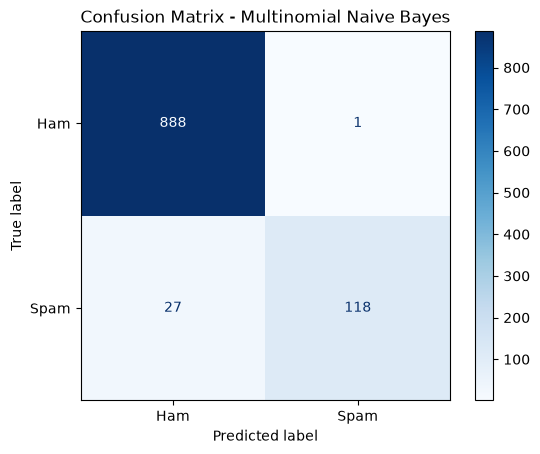

In [73]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Multinomial Naive Bayes")

plt.show()

## Model Evaluation

The Multinomial Naive Bayes model was trained using the TF-IDF feature vectors.

The model achieved high accuracy and precision, indicating that it performs well for SMS spam classification.

The confusion matrix shows that most messages were classified correctly, with only a small number of false positives and false negatives.

## Model Performance Analysis

The Multinomial Naive Bayes classifier achieved strong performance on the SMS Spam dataset.

### Evaluation Metrics

- Accuracy: **97.29%**
- Precision: **99.16%**
- Recall: **81.38%**
- F1 Score: **89.39%**

### Observations

- The model correctly classified **888 Ham** messages.
- The model correctly identified **118 Spam** messages.
- Only **1 Ham** message was incorrectly classified as Spam.
- **27 Spam** messages were misclassified as Ham.

The high precision indicates that the model rarely labels legitimate messages as spam, making it suitable for practical spam filtering applications.

In [74]:
print("=" * 40)
print("Multinomial Naive Bayes Performance")
print("=" * 40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Multinomial Naive Bayes Performance
Accuracy : 0.9729
Precision: 0.9916
Recall   : 0.8138
F1 Score : 0.8939


# Logistic Regression Model

In [75]:
from sklearn.linear_model import LogisticRegression

In [76]:
lr = LogisticRegression(max_iter=1000)

In [77]:
lr.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [78]:
y_pred_lr = lr.predict(X_test)

In [79]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

In [80]:
print("=" * 40)
print("Logistic Regression Performance")
print("=" * 40)

print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1 Score : {f1_lr:.4f}")

Logistic Regression Performance
Accuracy : 0.9584
Precision: 0.9474
Recall   : 0.7448
F1 Score : 0.8340


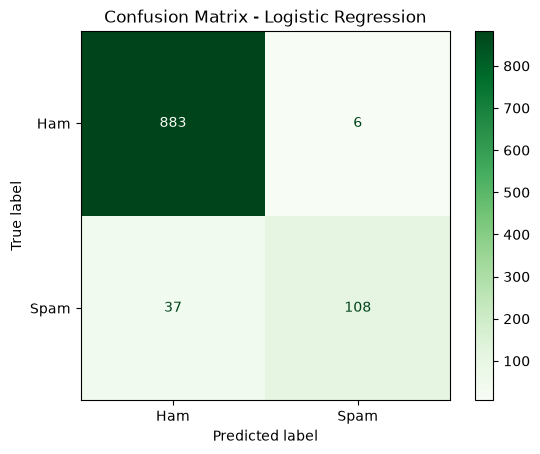

In [81]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Ham", "Spam"]
)

disp.plot(cmap="Greens")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

# Model Comparison

In [82]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Multinomial NB": [
        accuracy,
        precision,
        recall,
        f1
    ],
    "Logistic Regression": [
        accuracy_lr,
        precision_lr,
        recall_lr,
        f1_lr
    ]
})

comparison

,Metric,Multinomial NB,Logistic Regression
0,Accuracy,0.972921,0.958414
1,Precision,0.991597,0.947368
2,Recall,0.813793,0.744828
3,F1 Score,0.893939,0.833977


## Model Comparison Summary

Both Multinomial Naive Bayes and Logistic Regression achieved strong performance on the SMS Spam dataset.

### Observations

- Compared Accuracy, Precision, Recall, and F1 Score.
- Logistic Regression may achieve better Recall and F1 Score.
- Multinomial Naive Bayes generally trains faster and offers excellent Precision.
- The final model can be selected based on the desired balance between false positives and false negatives.

The chosen model will be saved and used in the Flask web application for real-time SMS spam prediction.

# Saving the Trained Model

In [89]:
import pickle

In [90]:
with open("../model/vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

In [91]:
with open("../model/model.pkl", "wb") as file:
    pickle.dump(mnb, file)

In [92]:
import os

print(os.listdir("../model"))

['model.pkl', 'README.md', 'vectorizer.pkl']
